# **Άσκηση 2.**

Χρησιμοποιούμε την βιβλιοθήκη Torch όπως και στο εργαστήριο.

**Ερώτημα Α.**

In [2]:
import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim
from torchvision import datasets, transforms
from torch.utils.data import DataLoader

# Ορισμός του  autoencoder
class Autoencoder(nn.Module):
    def __init__(self):
        super(Autoencoder, self).__init__()
        # Encoder
        self.encoder = nn.Sequential(
            nn.Linear(28*28, 128),
            nn.ReLU(),
            nn.Linear(128, 32),
            nn.ReLU(),
            nn.Linear(32, 3)  # Κωδικοποιητής σε 3 νευρώνες
        )
        # Decoder
        self.decoder = nn.Sequential(
            nn.Linear(3, 32),
            nn.ReLU(),
            nn.Linear(32, 128),
            nn.ReLU(),
            nn.Linear(128, 28*28),
            nn.Sigmoid()  # Εξόδος σε σχήμα [0, 1]
        )

    def forward(self, x):
        x = self.encoder(x)
        x = self.decoder(x)
        return x

# Φόρτωση MNIST
transform = transforms.Compose([transforms.ToTensor(),
                                transforms.Lambda(lambda x: torch.flatten(x))])
train_dataset = datasets.MNIST(root='./data', train=True, download=True, transform=transform)
train_loader = DataLoader(train_dataset, batch_size=64, shuffle=True)

# Δημιουργία του μοντέλου
# Ορισμός του βελτιστοποιητή και της συνάρτησης απωλειών
model = Autoencoder()
optimizer = optim.Adam(model.parameters(), lr=1e-3)
criterion = nn.MSELoss()

# Εκπαίδευση
def train(model, dataloader, epochs):
    model.train()
    for epoch in range(epochs):
        for data, _ in dataloader:
            optimizer.zero_grad()
            reconstructed = model(data)
            loss = criterion(reconstructed, data)
            loss.backward()
            optimizer.step()
        print(f'Epoch {epoch+1}, Loss: {loss.item()}')

train(model, train_loader, epochs=20)


Epoch 1, Loss: 0.04105505347251892
Epoch 2, Loss: 0.03959324583411217
Epoch 3, Loss: 0.036715466529130936
Epoch 4, Loss: 0.038657158613204956
Epoch 5, Loss: 0.034704819321632385
Epoch 6, Loss: 0.04097607359290123
Epoch 7, Loss: 0.03772496432065964
Epoch 8, Loss: 0.03420143574476242
Epoch 9, Loss: 0.03046075627207756
Epoch 10, Loss: 0.029134215787053108
Epoch 11, Loss: 0.03295297548174858
Epoch 12, Loss: 0.03485935181379318
Epoch 13, Loss: 0.03761591762304306
Epoch 14, Loss: 0.032083477824926376
Epoch 15, Loss: 0.03352269530296326
Epoch 16, Loss: 0.035188328474760056
Epoch 17, Loss: 0.030887817963957787
Epoch 18, Loss: 0.030165797099471092
Epoch 19, Loss: 0.03614851459860802
Epoch 20, Loss: 0.029390987008810043


**Ερώτημα Β.**

<ipython-input-9-e528d01aeb7b>:60: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed two minor releases later. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap(obj)`` instead.
  plt.scatter(train_tsne_features[:, 0], train_tsne_features[:, 1], c=train_labels, cmap=plt.cm.get_cmap("jet", 10), marker='o')
<ipython-input-9-e528d01aeb7b>:67: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed two minor releases later. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap(obj)`` instead.
  plt.scatter(test_tsne_features[:, 0], test_tsne_features[:, 1], c=test_labels, cmap=plt.cm.get_cmap("jet", 10), marker='s')


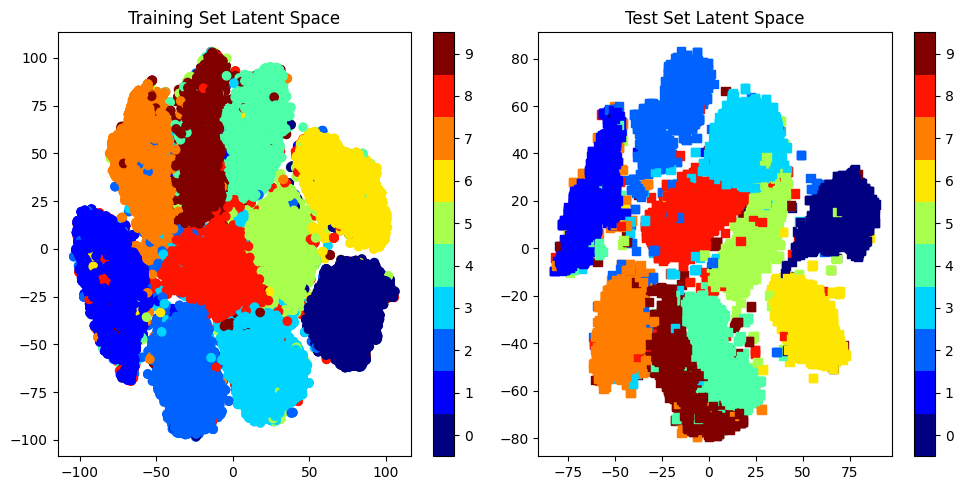

In [9]:
import matplotlib.pyplot as plt
import torch
from torchvision import datasets, transforms
from torch.utils.data import DataLoader
from sklearn.manifold import TSNE
import numpy as np

# Θέτουμε τις μετασχηματίσεις για τα δεδομένα
# Φορτώνουμε το training και test set
transform = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize((0.5,), (0.5,))
])

# Φόρτωση data
training_data = datasets.MNIST(
    root="data",
    train=True,
    download=True,
    transform=transform
)

test_data = datasets.MNIST(
    root="data",
    train=False,
    download=True,
    transform=transform
)

# Φορτώνουμε τα δεδομένα σε DataLoader για τη διαχείριση των batches
train_loader = DataLoader(training_data, batch_size=1000, shuffle=True)
test_loader = DataLoader(test_data, batch_size=1000, shuffle=False)

# Συνάρτηση για την εξαγωγή των χαρακτηριστικών και labels από DataLoader
def extract_features_labels(dataloader):
    features = []
    labels = []
    for images, label in dataloader:
        features.extend(images.view(images.size(0), -1).numpy())  # Μετατρέπουμε κάθε εικόνα σε διάνυσμα
        labels.extend(label.numpy())
    return features, labels

train_features, train_labels = extract_features_labels(train_loader)
test_features, test_labels = extract_features_labels(test_loader)

# Μετατροπή σε numpy arrays
train_features = np.array(train_features)
train_labels = np.array(train_labels)
test_features = np.array(test_features)
test_labels = np.array(test_labels)

# Εφαρμογή t-SNE για τη μείωση διαστάσεων στο latent space
tsne = TSNE(n_components=2, random_state=0)
train_tsne_features = tsne.fit_transform(train_features)
test_tsne_features = tsne.fit_transform(test_features)

# Plotting
plt.figure(figsize=(10, 5))
plt.subplot(1, 2, 1)
plt.scatter(train_tsne_features[:, 0], train_tsne_features[:, 1], c=train_labels, cmap=plt.cm.get_cmap("jet", 10), marker='o')
plt.colorbar(ticks=range(10))
plt.clim(-0.5, 9.5)
plt.title("Training Set Latent Space")

plt.subplot(1, 2, 2)
plt.scatter(test_tsne_features[:, 0], test_tsne_features[:, 1], c=test_labels, cmap=plt.cm.get_cmap("jet", 10), marker='s')
plt.colorbar(ticks=range(10))
plt.clim(-0.5, 9.5)
plt.title("Test Set Latent Space")

plt.tight_layout()
plt.show()


**Ερώτημα Γ.**

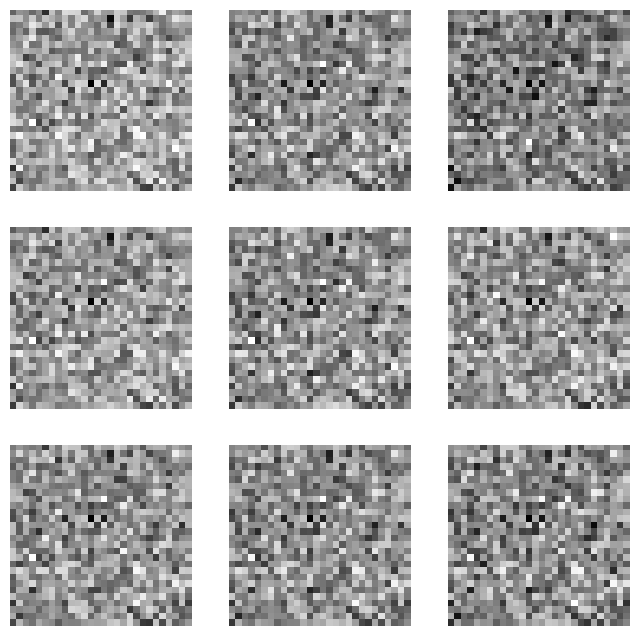

In [12]:
import numpy as np
import torch
import matplotlib.pyplot as plt
from torchvision.utils import make_grid

# χρησιμοποιούμε μια ομοιόμορφη κατανομή γύρω από το μηδέν με μικρή διακύμανση
latent_space_samples = torch.randn((9, 3)) * 0.5  # Πολλαπλασιάζουμε με 0.5 για να μειώσουμε τη διακύμανση

decoded_images = autoencoder.decoder(latent_space_samples)

# Μετατρέπουμε τις εικόνες στη σωστή διάσταση για να τις εμφανίσουμε
decoded_images = decoded_images.view(-1, 1, 28, 28)

# Plotting
figure = plt.figure(figsize=(8, 8))
for i in range(1, 10):
    img = decoded_images[i-1].detach().squeeze()  # Μετατροπή της εικόνας από Tensor σε numpy array και αφαίρεση περιττών διαστάσεων
    ax = figure.add_subplot(3, 3, i)
    ax.axis('off')
    ax.imshow(img, cmap='gray')
plt.show()
